#📌 Extracción

In [7]:
import pandas as pd
datosCrudos = pd.read_json('TelecomX_Data.json')
datosCrudos

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformación

In [8]:
datosCrudos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [11]:
print(datosCrudos.dtypes)

customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object


In [12]:
customer_df = pd.json_normalize(datosCrudos['customer'])
phone_df = pd.json_normalize(datosCrudos['phone'])
internet_df = pd.json_normalize(datosCrudos['internet'])
account_df = pd.json_normalize(datosCrudos['account'])

datosLimpios = pd.concat([datosCrudos[['customerID','Churn']], customer_df, phone_df, internet_df, account_df], axis=1)
datosLimpios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [13]:
print('datos nulos')
datosLimpios.isnull().sum()

datos nulos


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [15]:
print('datos duplicados')
duplicados = datosLimpios.duplicated().sum()
print(duplicados)

datos duplicados
0


In [16]:
total_charges_temp = pd.to_numeric(datosLimpios['Charges.Total'], errors='coerce')
nulos_formato = total_charges_temp.isnull().sum()
print(f"\nErrores de formato en Charges.Total (espacios vacíos o texto): {nulos_formato}")


Errores de formato en Charges.Total (espacios vacíos o texto): 11


In [17]:
print("\n--- Valores únicos en la variable objetivo (Churn) ---")
print(datosLimpios['Churn'].unique())


--- Valores únicos en la variable objetivo (Churn) ---
['No' 'Yes' '']


In [18]:
datosLimpios = datosLimpios[datosLimpios['Churn'] != ''].copy()

In [19]:
print("\n--- Valores únicos en la variable objetivo (Churn) ---")
print(datosLimpios['Churn'].unique())


--- Valores únicos en la variable objetivo (Churn) ---
['No' 'Yes']


In [20]:
datosLimpios['Charges.Total'] = pd.to_numeric(datosLimpios['Charges.Total'], errors='coerce').fillna(0)

In [21]:
total_charges_temp = pd.to_numeric(datosLimpios['Charges.Total'], errors='coerce')
nulos_formato = total_charges_temp.isnull().sum()
print(f"\nErrores de formato en Charges.Total (espacios vacíos o texto): {nulos_formato}")


Errores de formato en Charges.Total (espacios vacíos o texto): 0


In [38]:
print("Valores únicos en 'gender':", datosLimpios['gender'].unique())

vacios_genero = (datosLimpios['gender'] == '').sum()
nulos_genero = datosLimpios['gender'].isnull().sum()

print(f"Espacios vacíos: {vacios_genero}")
print(f"Valores nulos (NaN): {nulos_genero}")

Valores únicos en 'gender': ['Female' 'Male']
Espacios vacíos: 0
Valores nulos (NaN): 0


## Opcional

In [25]:
datosLimpios['Cuentas_Diarias'] = (datosLimpios['Charges.Monthly'] / 30).round(2)

print(datosLimpios[['Charges.Monthly', 'Cuentas_Diarias']].head())

   Charges.Monthly  Cuentas_Diarias
0             65.6             2.19
1             59.9             2.00
2             73.9             2.46
3             98.0             3.27
4             83.9             2.80


In [26]:
datosLimpios

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.84
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.68
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26


#📊 Carga y análisis

In [28]:
resumen = datosLimpios.describe().T
resumen['median'] = datosLimpios.median(numeric_only=True)
print(resumen[['mean', 'median', 'std', 'min', 'max']])

                        mean   median          std    min      max
SeniorCitizen       0.162147     0.00     0.368612   0.00     1.00
tenure             32.371149    29.00    24.559481   0.00    72.00
Charges.Monthly    64.761692    70.35    30.090047  18.25   118.75
Charges.Total    2279.734304  1394.55  2266.794470   0.00  8684.80
Cuentas_Diarias     2.158675     2.34     1.003088   0.61     3.96


In [29]:
print("\n--- Distribución de la Evasión (Churn) ---")
print(datosLimpios['Churn'].value_counts(normalize=True) * 100)


--- Distribución de la Evasión (Churn) ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [30]:
print("\n--- Promedio de Cargos Mensuales por Grupo ---")
print(datosLimpios.groupby('Churn')['Charges.Monthly'].mean())


--- Promedio de Cargos Mensuales por Grupo ---
Churn
No     61.265124
Yes    74.441332
Name: Charges.Monthly, dtype: float64


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

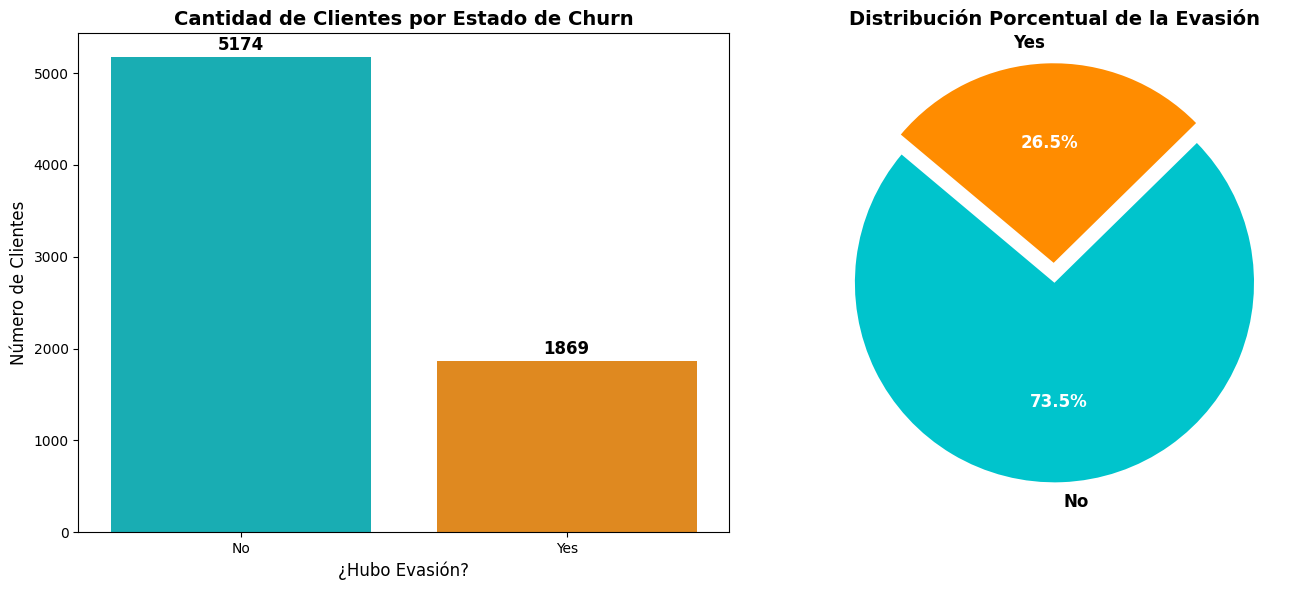

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

colores_contraste = ['#00C4CC', '#FF8C00']

sns.countplot(x='Churn', hue='Churn', data=datosLimpios, ax=ax[0], palette=colores_contraste, legend=False)
ax[0].set_title('Cantidad de Clientes por Estado de Churn', fontsize=14, fontweight='bold')
ax[0].set_xlabel('¿Hubo Evasión?', fontsize=12)
ax[0].set_ylabel('Número de Clientes', fontsize=12)

for p in ax[0].patches:
    if p.get_height() > 0:
        ax[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                    textcoords='offset points', fontweight='bold')

churn_counts = datosLimpios['Churn'].value_counts()
patches, texts, autotexts = ax[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
                                      startangle=140, colors=colores_contraste, explode=(0, 0.1),
                                      textprops={'fontsize': 12, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')

ax[1].set_title('Distribución Porcentual de la Evasión', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


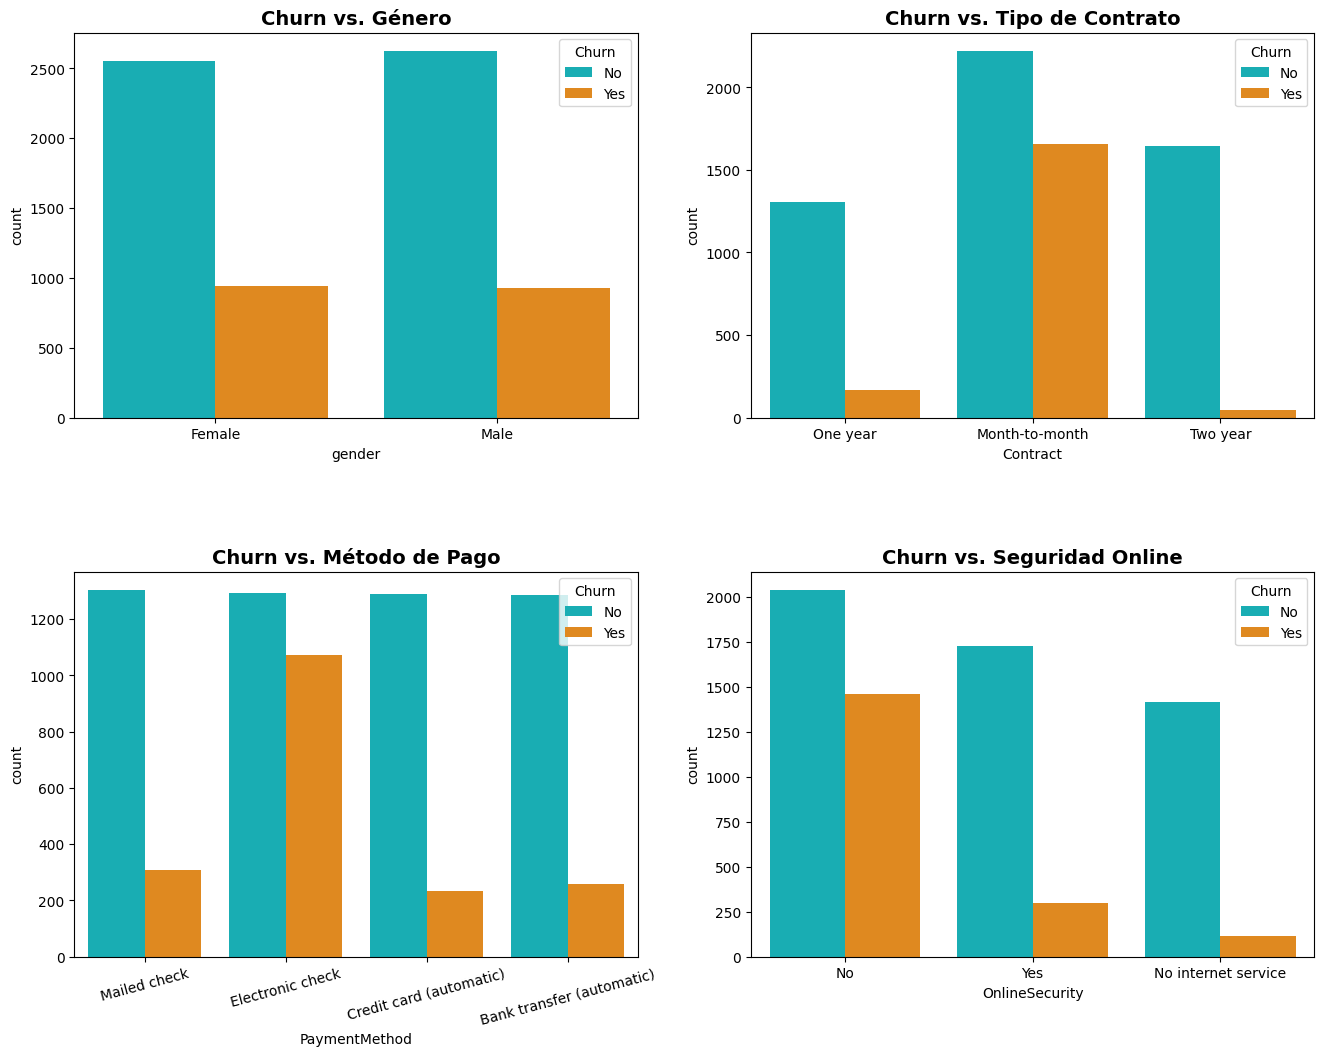

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4)

sns.countplot(data=datosLimpios, x='gender', hue='Churn', ax=axes[0, 0], palette=colores_contraste)
axes[0, 0].set_title('Churn vs. Género', fontsize=14, fontweight='bold')

sns.countplot(data=datosLimpios, x='Contract', hue='Churn', ax=axes[0, 1], palette=colores_contraste)
axes[0, 1].set_title('Churn vs. Tipo de Contrato', fontsize=14, fontweight='bold')

sns.countplot(data=datosLimpios, x='PaymentMethod', hue='Churn', ax=axes[1, 0], palette=colores_contraste)
axes[1, 0].set_title('Churn vs. Método de Pago', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)

sns.countplot(data=datosLimpios, x='OnlineSecurity', hue='Churn', ax=axes[1, 1], palette=colores_contraste)
axes[1, 1].set_title('Churn vs. Seguridad Online', fontsize=14, fontweight='bold')

plt.show()

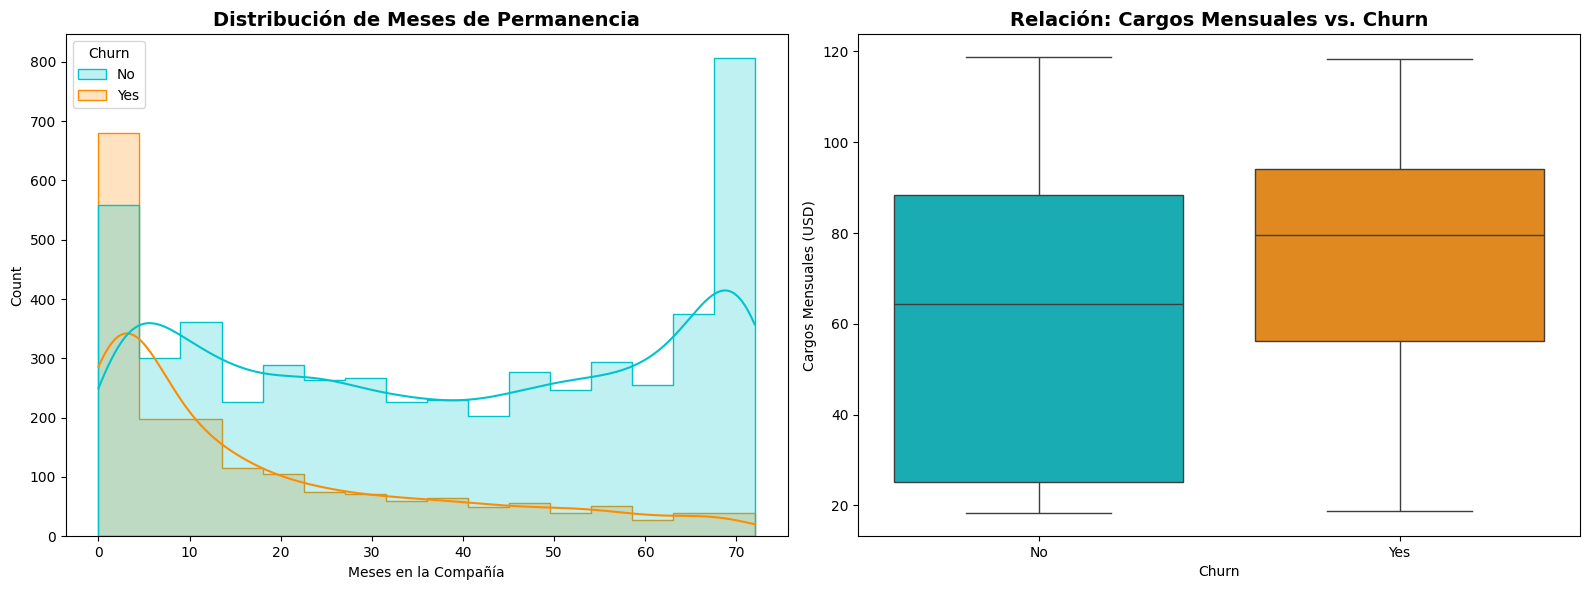

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colores_contraste = ['#00C4CC', '#FF8C00']

sns.histplot(data=datosLimpios, x='tenure', hue='Churn', kde=True, ax=axes[0],
             palette=colores_contraste, element="step", legend=True)
axes[0].set_title('Distribución de Meses de Permanencia', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Meses en la Compañía')

sns.boxplot(data=datosLimpios, x='Churn', y='Charges.Monthly', hue='Churn',
            ax=axes[1], palette=colores_contraste, legend=False)
axes[1].set_title('Relación: Cargos Mensuales vs. Churn', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cargos Mensuales (USD)')

plt.tight_layout()
plt.show()

#📄Informe final


# Informe Final: Analisis de Evasion de Clientes (Churn) - Telecom X

## 1. Introduccion
El objetivo de este analisis es identificar los factores determinantes en la perdida de clientes de la empresa Telecom X. La retencion es un pilar fundamental para la sostenibilidad financiera, dado que los costos de adquisicion de nuevos clientes superan ampliamente a los de mantencion. Este informe documenta el proceso desde el tratamiento de datos hasta la generacion de hallazgos estrategicos para reducir la tasa de evasion actual observada.

---

## 2. Limpieza y Tratamiento de Datos
Para garantizar la integridad de los resultados, se siguieron los siguientes pasos tecnicos:

* **Importacion y Aplanado**: Se procesaron datos en formato JSON, normalizando estructuras anidadas para obtener un dataset plano de 21 columnas iniciales.
* **Correccion de Inconsistencias**: Se eliminaron filas con valores vacios en la variable objetivo 'Churn' y se gestionaron los errores de formato en 'Charges.Total' convirtiendolos a tipo numerico.
* **Ingenieria de Caracteristicas**: Se incorporo la columna 'Cuentas_Diarias' (Cargos Mensuales / 30) para evaluar el gasto del cliente en una escala de consumo cotidiano.

---

## 3. Analisis Exploratorio de Datos (EDA)
A traves de las visualizaciones generadas, se identificaron los siguientes patrones criticos:

* **Distribucion de Evasion**: Se confirmo una tasa de abandono del 26.5% (1,869 clientes).
* **Perfil de Riesgo**: La fuga se concentra en clientes con contratos "Mes a Mes" y aquellos que utilizan "Electronic check" como metodo de pago.
* **Factor Economico**: Los clientes que cancelan presentan cargos mensuales promedio de 74.44 USD, significativamente superiores a los 61.26 USD de los clientes que permanecen.
* **Rango Critico de Permanencia**: El mayor riesgo de abandono ocurre durante el primer mes de servicio.

---

## 4. Conclusiones e Insights
* **Sensibilidad al Precio**: Existe un umbral de fatiga financiera cercano a los 70-80 USD mensuales que dispara la probabilidad de evasion.
* **Efecto de Anclaje**: La ausencia de servicios de valor agregado, como Seguridad Online o Soporte Tecnico, esta fuertemente correlacionada con una mayor tasa de Churn.
* **Estabilidad Contractual**: Los contratos a largo plazo (1 y 2 años) actuan como la herramienta de retencion mas efectiva.

---

## 5. Recomendaciones Estrategicas
1. **Fidelizacion Temprana**: Implementar un programa de acompañamiento (Onboarding) durante los primeros 90 dias para mitigar el pico de evasion inicial.
2. **Incentivos de Migracion**: Ofrecer beneficios para motivar el cambio de contratos mensuales hacia planes anuales.
3. **Paquetes de Valor**: Incluir servicios de seguridad en planes de alto consumo para aumentar el valor percibido.
4. **Revision de Canales de Pago**: Fomentar el uso de pagos automaticos para reducir la friccion detectada en los pagos manuales.